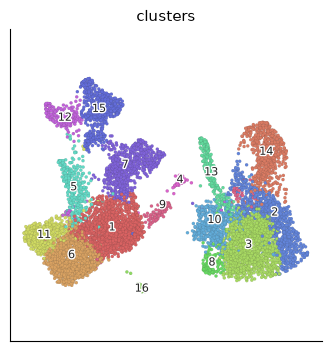

In [1]:
from pathlib import Path
from tempfile import TemporaryDirectory

import numpy as np
import pandas as pd

import scarf

scarf.configure_output(level="WARNING", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "kang_15K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(
    f"{dataset}/data.zarr",
    default_assay="RNA",
    nthreads=4,
)
run = ds.pipeline.open(label="docs_default")
ds.plots.embedding(run=run, layout="umap", color_by="clusters")

In [2]:
marker_ref = run["markers"]
cluster_values = np.asarray(run.cells.fetch("clusters"))
group_id = pd.Series(cluster_values).value_counts().index[0]
markers = ds.get_markers(
    marker=marker_ref,
    group_id=group_id,
    min_score=-1,
    min_frac_exp=-1,
)
markers[
    [
        "feature_name",
        "score",
        "frac_exp",
        "auc",
        "p_value",
        "p_value_adjusted",
    ]
].head()

,feature_name,score,frac_exp,auc,p_value,p_value_adjusted
0,TMEM173,0.30161,0.15055,0.56048,6.853537e-78,1.507567e-75
1,GPR171,0.29051,0.18672,0.57319,5.928195e-89,1.541980e-86
2,RP11-1399P15.1,0.26684,0.08635,0.53675,4.205776e-57,6.516210e-55
3,GATA3,0.22758,0.12472,0.54595,2.342278e-47,3.046243e-45
4,SETD2,0.22306,0.20148,0.57383,7.565200e-75,1.576526e-72


In [3]:
# Compare two clusters that are present in the Kang dataset.
result = ds.run_statistical_testing(
    ["MALAT1"],
    run["clusters"],
    groups=[1, 2],
    test="welch",
    alternative="greater",
)

# Pin retrieval to the exact immutable result returned by statistical testing.
loaded = ds.get_statistical_tests(result.artifact)
loaded.tables["MALAT1"]

/home/parashar/scarf/scarf/datastore/_operations/features.py:3035: UserWarning: Cell-level statistical testing treats each cell as an independent observation. Results are descriptive distribution testing, not population-level condition or disease inference; this applies equally to explicitly requested parametric tests on single cells (welch, one_way_anova), which must survive zero-inflated, non-normal data. Aggregate cells to biological samples with sample_by for sample-level summary testing.
  outcomes[key_label] = compare_group_distributions(


,group_1,group_2,n_1,n_2,t_statistic,df,mean_1,mean_2,mean_difference,p_value,p_value_adjusted
0,1,2,1355,797,52.770935,2086.148876,69.379568,32.804751,36.574817,0.0,0.0


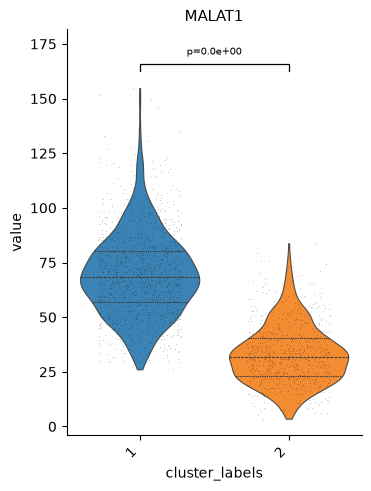

In [4]:
# The plotted selection and test design must match the stored result.
ds.plots.distribution(
    ["MALAT1"],
    grouping=run["clusters"],
    groups=[1, 2],
    kind="violin",
    stats_results=result.artifact,
)

In [5]:
group_sizes = (
    pd.Series(cluster_values, name="group")
    .astype(str)
    .value_counts()
    .sort_index()
)

In [6]:
bulk, fractions = ds.make_bulk(
    run["clusters"],
    from_assay="RNA",
    aggr_type="sum",
    feature_label="name",
    return_fraction=True,
)
totals = bulk.sum().rename("total_counts")
totals.index = totals.index.astype(str)
sample_metadata = pd.concat(
    [group_sizes.rename("n_cells"), totals],
    axis=1,
)
sample_metadata

,n_cells,total_counts
1,1355,2038640
10,504,1511174
11,463,668233
12,220,466782
13,231,855470
14,595,1718773
15,614,919571
16,30,108064
2,797,2291007
3,1306,2820536


In [7]:
top_features = bulk.sum(axis=1).sort_values(ascending=False).head(8).index
bulk.loc[top_features], fractions.loc[top_features]

(             1       2       3     4      5       6      7      8      9  \
 FTH1     99580  368196  461990  2961  11493   27602  25997  23102  20109   
 MALAT1  140070   74537  110319  6373  35115  109491  79643   8428  11850   
 FTL       4548  220532  247302  3719   1854    2578   2839   8578   8526   
 B2M      58150   66226   75740  2707  11295   36626  42713   4590   7201   
 TMSB4X   78982   40530   49904  2194  11124   42199  43677   2196   7994   
 RPL10    27142    9508   13586   794   3806   20361  11013    999   1840   
 TIMP1      677   28509   45750    12    144     228    253   3436   1254   
 RPS2     27246    8158   11669   901   3485   18954  11360    925   1762   
 
             10     11     12     13      14     15    16  
 FTH1    176176   8667   6705  67931  277861  26161  3264  
 MALAT1   76290  48320  24169  37795   93748  65960  2808  
 FTL      84888   1638   2923  24820   65589   3333  1088  
 B2M      42695  18449  11479  24523   59951  26847  1148  
 TMSB

In [8]:
export_directory = TemporaryDirectory()
counts_csv = Path(export_directory.name) / "pseudobulk_counts.csv"
metadata_csv = Path(export_directory.name) / "pseudobulk_metadata.csv"

bulk.to_csv(counts_csv)
sample_metadata.index.name = "group"
sample_metadata.to_csv(metadata_csv)

pd.read_csv(counts_csv, index_col=0, nrows=5).iloc[:, :5]

,1,2,3,4,5
RP11-34P13.8,0,0,1,0,0
AL627309.1,1,0,0,0,0
RP11-206L10.2,0,0,0,0,0
RP11-206L10.9,0,1,0,0,0
FAM87B,0,0,0,0,0
